---

# 📊 Data Visualization Part 1: The Ultimate Matplotlib Workbook

## 📦 Setup & Mock Data Initialization


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. IPL Time Series Data (Line Plots)
batsman = pd.DataFrame({
    'index': [2015, 2016, 2017, 2018, 2019, 2020],
    'V Kohli': [500, 973, 308, 530, 464, 466],
    'RG Sharma': [482, 489, 333, 286, 405, 332],
    'MS Dhoni': [372, 284, 290, 455, 416, 200]
})

# 2. Batsman Stats (Scatter Plots)
batsman_stats = pd.DataFrame({
    'batsman': ['Kohli', 'Rohit', 'Dhoni', 'Rahul', 'Warner'],
    'avg': [55.5, 48.2, 42.1, 47.6, 48.2],
    'strike_rate': [135.2, 140.5, 135.8, 137.4, 141.5],
    'runs': [6624, 5879, 4978, 3273, 5449]
})

# 3. Sales Data (Bar Charts)
sales_data = pd.DataFrame({
    'product': ['Laptop', 'Phone', 'Tablet', 'Monitor'],
    '2022': [180, 220, 110, 90],
    '2023': [200, 250, 120, 100]
})

# 4. Tips Dataset
tips = sns.load_dataset('tips')

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


---

# 📘 MODULE 1: Types of Data & Chart Selection

### 🧠 Concept
Before writing a single line of code, you must classify your data. **Data type dictates chart type.**

### 💡 Why It Exists
Choosing the wrong chart is the biggest beginner mistake. If you use a line chart for categorical data, you imply a mathematical continuity that doesn't exist.

### 🧩 Mental Model
**"The Bucket vs. The Ruler"**
*   **Categorical Data** goes into **Buckets** (Labels like Apple, Banana, City).
*   **Numerical Data** is measured on a **Ruler** (Continuous scale like Price, Age, Temperature).

### 📊 ASCII Diagram: Visual Decision Tree
```text
START: What is your data?
│
├── Numerical (Ruler)
│   ├── 1 Variable (Distribution) ──> Histogram
│   └── 2 Variables (Relationship) ─> Scatter / Line Plot
│
└── Categorical (Buckets)
    ├── Comparison (Who has most?) ─> Bar Chart
    └── Contribution (% of whole) ──> Pie Chart
```

### 💻 Syntax
*Conceptual framework, no specific Matplotlib syntax.*

### 💻 Code Example

In [10]:
# Checking data types in Pandas
df = pd.DataFrame({
    'Age': [25, 30, 35],         # Numerical (Ruler)
    'City': ['NY', 'LA', 'SF'],  # Categorical (Bucket)
    'Salary': [50000, 80000, 120000]   # Numerical (Ruler)
})
print(df.dtypes)
print("\nData Types:")
print(df.dtypes)

Age       int64
City        str
Salary    int64
dtype: object

Data Types:
Age       int64
City        str
Salary    int64
dtype: object


### ⚠️ Common Mistakes
*   **The Continuity Trap:** Using a Line Chart for categorical data (e.g., connecting "Apple" to "Banana" with a line implies a trend).
*   **The Pie Chart Trap:** Using a Pie Chart for 20 categories (human eyes cannot compare 20 different angles).

### 🎤 Interview Questions
1.  **Q:** What is the fundamental difference between Numerical and Categorical data?
    **A:** Numerical represents quantities measured on a scale (math can be performed). Categorical represents discrete groups or labels.
2.  **Q:** Why can't I use a Line Chart for Categorical data?
    **A:** Line charts imply continuity and order (like time). Categories have no inherent mathematical order.

### 🎯 Practice Tasks
**🟢 Easy Tasks (3)**
1. Identify if 'Temperature' is numerical or categorical.
2. Identify if 'Product Category' is numerical or categorical.
3. Identify if 'Number of Employees' is numerical or categorical.

**🟡 Medium Tasks (3)**
1. You want to show 'Monthly Sales Trend'. Which chart?
2. You want to show 'Distribution of Student Marks'. Which chart?
3. You want to show 'Market Share of 4 Companies'. Which chart?

**🔴 Hard Tasks (3)**
1. You want to show 'Market Share of 20 Companies'. Which chart? Why is Pie bad here?
2. You want to show 'Time taken to deliver' vs 'Distance'. Which chart?
3. You want to compare 'Revenue' across 5 'Regions'. Which chart?

### 🐛 Debugging Challenges (2)
1.  **Why is this wrong?** `plt.pie(age_column)`
    *Answer: Pie charts require categorical labels and numerical sizes. A single numerical column has no categories to slice.*
2.  **Why is this misleading?** `plt.plot(['Apple', 'Banana', 'Cherry'], [10, 20, 15])`
    *Answer: The line connecting them implies 'Banana' is mathematically between 'Apple' and 'Cherry', which is false.*

### 🚀 Real-World Mini Project
**E-commerce Dashboard Planning:** You are given a raw dataset of online orders (Order ID, Product Category, Price, Order Date, Customer Rating). Write down which chart you would use to show:
(a) Sales trend over the year. *(Line Plot)*
(b) Average price per category. *(Bar Chart)*
(c) Distribution of customer ratings. *(Histogram)*
(d) Market share of top 5 product categories. *(Pie Chart)*

### 📝 Revision Questions
1. What are the two main types of data?
2. What chart is best for a single numerical variable?


---
# 📘 MODULE 2: 2D Line Plots (Time Series)

### 🧠 Concept
Line plots connect data points with straight lines.

### 💡 Why It Exists
To show **continuity, trends, and changes** over an ordered axis (usually time).

### 🧩 Mental Model
**"Connect-the-dots tracking a journey."** The line represents the path the data took between measurements.

### 📊 ASCII Diagram: Reading a Line Plot
```text
Sales
  ↑
70|          * (Peak)
60|       *
50|    *
40| *
30|    * (Dip/Outlier)
  +--------------→ Year
Questions to ask: What is the overall trend? Where is the peak? Are there sudden drops?
```

### 💻 Syntax
`plt.plot(x, y, color='...', linestyle='...', marker='...', label='...')`

### 💻 Code Example

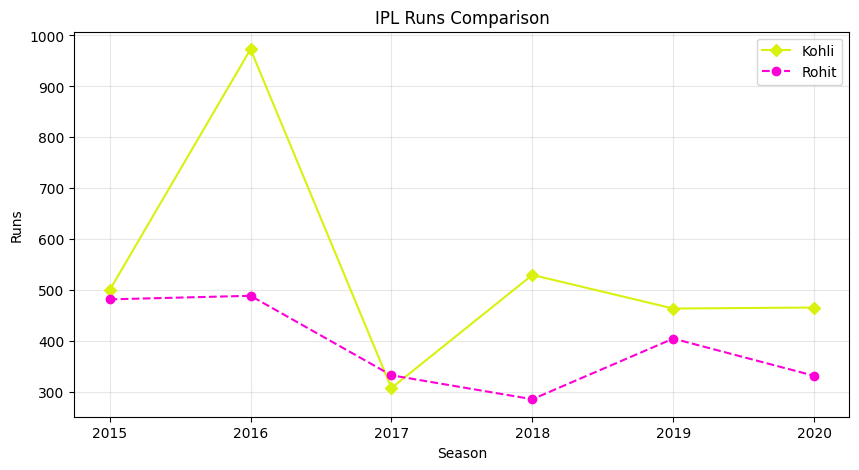

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(batsman['index'], batsman['V Kohli'], color='#D9F10F', marker='D', label='Kohli')
plt.plot(batsman['index'], batsman['RG Sharma'], color='#FC00D6', marker='o', linestyle='--', label='Rohit')
plt.title('IPL Runs Comparison')
plt.xlabel('Season')
plt.ylabel('Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### ⚠️ Common Mistakes
*   **The Overplotting Trap:** Plotting 5 lines without a legend or distinct colors.
*   **The Outlier Squish:** Letting one massive outlier dictate the Y-axis scale, making the rest of the data look flat.

### 🎤 Interview Questions
1.  **Q:** How do you limit the visible area of a plot without deleting the underlying data?
>    **A:** Use `plt.xlim(start, end)` and `plt.ylim(bottom, top)`.
2.  **Q:** What is the difference between `plt.plot()` and `plt.scatter()`?
>    **A:** `plot()` connects points (trends), `scatter()` shows individual points (correlation).

### 🎯 Practice Tasks
**🟢 Easy Tasks (3)**
1. Plot `x=[1,2,3,4]`, `y=[10,20,30,40]`.
2. Add a title, xlabel, and ylabel to the plot.
3. Change the line color to red and add a grid.

**🟡 Medium Tasks (3)**
1. Plot `y = x²` for x from -5 to 5.
2. Plot two lines (sin(x) and cos(x)) on the same graph with a legend.
3. Use `plt.xlim()` to zoom into a specific section of a noisy line plot.

**🔴 Hard Tasks (3)**
1. Plot 4 different IPL players on the same graph, using different HEX colors, line styles, and markers.
2. Add annotations (`plt.annotate`) to highlight the highest peak in a time series.
3. Create a subplot with 2 rows: one with a linear scale, one with a log scale.

### 🐛 Debugging Challenges (2)
1.  **Why doesn't this work?** `plt.plot(x); plt.plot(y)` when `x` has 5 elements and `y` has 10?
    *Answer: `plt.plot(y)` plots `y` against its index (0 to 9). If you want x vs y, you must pass both: `plt.plot(x, y)`.*
2.  **Why are my multiple lines all the same color?**
    *Answer: You didn't specify the `color=` parameter, and you might be overwriting the plot instead of plotting on the same axes.*

### 🚀 Real-World Mini Project
**Stock Market Trend Analyzer:** Mock 1 year of daily closing prices for 2 tech stocks. Plot them on the same graph. Add a moving average line. Highlight the days where the stock dropped by more than 5% using scatter points overlaid on the line.

### 📝 Revision Questions
1. What is the primary use case for a line plot?
2. How do you add a legend to a plot?


---

# 📘 MODULE 3: Scatter Plots (Correlation)

### 🧠 Concept
Scatter plots display individual dots based on their X and Y values.

### 💡 Why It Exists
To find **relationships, correlations, and clusters** between two numerical variables.

### 🧩 Mental Model
**"A cloud of points."** If the cloud leans up, it's positive. If it leans down, it's negative. If it's a round blob, there's no correlation.

### 📊 ASCII Diagram: Correlation Visuals
```text
Positive Correlation   Negative Correlation   No Correlation
   *                      *                  *    *
  * *                    * *                   *
 *   *                  *   *               *
*     *                *     *             *    *
```

### 💻 Syntax
`plt.scatter(x, y, s=size, c=color, cmap='...', alpha=...)`

### 💻 Code Example


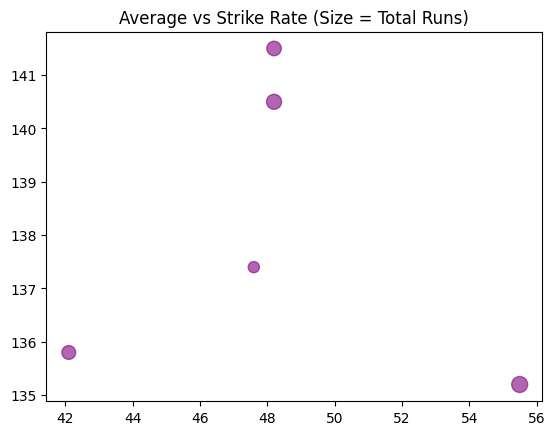

In [11]:
# Bubble Chart: Size mapped to a 3rd variable
plt.scatter(batsman_stats['avg'], batsman_stats['strike_rate'], 
            s=batsman_stats['runs']/50, alpha=0.6, c='purple')
plt.title('Average vs Strike Rate (Size = Total Runs)')
plt.show()


### ⚠️ Common Mistakes
*   **Correlation ≠ Causation:** Just because ice cream sales and shark attacks both go up in summer (positive correlation) doesn't mean ice cream causes shark attacks.
*   **Overplotting:** Plotting 10,000 points with `alpha=1.0` results in a solid blob of color. Fix: Use `alpha=0.3`.

### 🎤 Interview Questions
1.  **Q:** What is the difference between `plt.scatter()` and `plt.plot(x, y, 'o')`?
    **A:** `scatter()` allows varying size (`s`) and color (`c`) per point. `plot()` is faster but all points must share the same size/color.
2.  **Q:** When should scatter plots NOT be used?
    **A:** When analyzing time series data (use line plots) or categorical data (use bar charts).

### 🎯 Practice Tasks
**🟢 Easy Tasks (3)**
1. Create a basic scatter plot of `total_bill` vs `tip` from the tips dataset.
2. Change the marker to a triangle (`^`) and color to green.
3. Add a title and axis labels.

**🟡 Medium Tasks (3)**
1. Map the size of the dots (`s`) to the `size` column (Bubble chart).
2. Map the color (`c`) to a categorical column (e.g., `day`) using a colormap.
3. Add a colorbar to explain the color mapping.

**🔴 Hard Tasks (3)**
1. Create 4 subplots showing: Strong Positive, Weak Positive, Strong Negative, Weak Negative correlations using `np.random`.
2. Annotate specific outliers in a scatter plot with their row index or name.
3. Overlay a linear regression trendline on a scatter plot using `np.polyfit`.

### 🐛 Debugging Challenges (2)
1.  **Why does `plt.scatter(x, y, c=['red', 'blue'])` fail if `x` has 100 points?**
    *Answer: The `c` array must match the length of `x` and `y`, or be a single color string.*
2.  **Why is my scatter plot taking 10 seconds to render?**
    *Answer: You have too many points. Use `plt.plot(x, y, 'o', alpha=0.1)` which is highly optimized for speed, or use hexbin plots.*

### 🚀 Real-World Mini Project
**Player Performance Scout:** Create a scatter plot of IPL batsmen (Average vs Strike Rate). Size the bubbles by total runs scored. Color them by their team. Annotate the top 3 players by strike rate. Draw a vertical and horizontal line at the league average to create 4 performance quadrants.

### 📝 Revision Questions
1. What does a scatter plot help you find?
2. How do you handle overplotting in a scatter plot?


---

# 📘 MODULE 4: Bar Charts (Categorical Comparison)

### 🧠 Concept
Bar charts represent categorical data with rectangular bars.

### 💡 Why It Exists
To **compare discrete categories** or show rankings.

### 🧩 Mental Model
**"Comparing the heights of buildings."** The human eye is excellent at comparing the lengths/heights of rectangles aligned on a baseline.

### 📊 ASCII Diagram: Reading a Bar Chart
```text
Sales
100 | ██████████ (Best)
 80 | ████████
 50 | █████
 20 | ██ (Worst)
      A  B  C  D
Questions: Who is the best/worst? What is the difference between A and D?
```

### 💻 Syntax
*   Vertical: `plt.bar(x, height)`
*   Horizontal: `plt.barh(y, width)`
*   Stacked: `plt.bar(..., bottom=previous_values)`

### 💻 Code Example


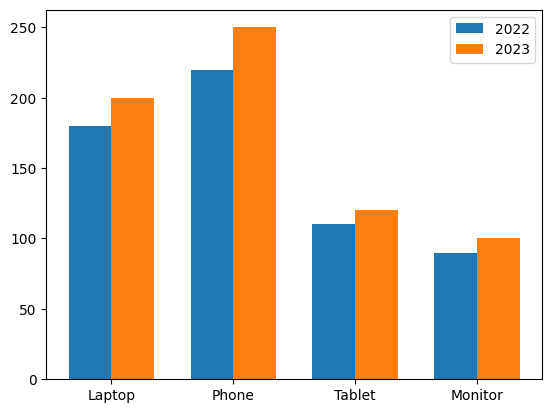

In [12]:
# Grouped Bar Chart (The Offset Trick)
x = np.arange(len(sales_data['product']))
width = 0.35
plt.bar(x - width/2, sales_data['2022'], width, label='2022')
plt.bar(x + width/2, sales_data['2023'], width, label='2023')
plt.xticks(x, sales_data['product'])
plt.legend()
plt.show()


### ⚠️ Common Mistakes
*   **The Overlapping Label Trap:** Long category names turn into a black blob. Fix: `plt.xticks(rotation=45)`.
*   **The 3D Trap:** Using 3D bars distorts the visual area and makes comparison impossible. Always use 2D.

### 🎤 Interview Questions
1.  **Q:** What is the difference between a Bar Chart and a Histogram?
    **A:** Bar Chart = Categorical X-axis, gaps between bars. Histogram = Numerical X-axis (bins), no gaps.
2.  **Q:** How do you create a stacked bar chart in Matplotlib?
    **A:** Plot the first bar normally. Plot the second bar using the same X values, but pass the first bar's Y values to the `bottom=` parameter.

### 🎯 Practice Tasks
**🟢 Easy Tasks (3)**
1. Create a simple vertical bar chart for 3 categories.
2. Create a horizontal bar chart using `plt.barh()`.
3. Change the color of each bar individually.

**🟡 Medium Tasks (3)**
1. Create a grouped (side-by-side) bar chart comparing 2 years of data.
2. Rotate X-axis labels by 45 degrees to prevent overlapping.
3. Add a horizontal grid to make reading values easier.

**🔴 Hard Tasks (3)**
1. Create a stacked bar chart showing the contribution of 3 products to total revenue per quarter.
2. Add the exact numerical value on top of each bar using `plt.text()`.
3. Create a stacked bar chart where each segment shows its percentage contribution.

### 🐛 Debugging Challenges (2)
1.  **Why do my long X-axis labels look like a black blob?**
    *Answer: Matplotlib doesn't auto-rotate text. Use `plt.xticks(rotation=45, ha='right')`.*
2.  **Why does my stacked bar chart look broken (bars floating)?**
    *Answer: The `bottom` array must be exactly the same length and order as the X-axis array.*

### 🚀 Real-World Mini Project
**Regional Sales Dashboard:** You have sales data for 4 regions across 4 quarters. Create a grouped bar chart to compare Q1 vs Q2 vs Q3 vs Q4 for each region. Then, create a stacked bar chart to show the total annual revenue per region and the contribution of each quarter.

### 📝 Revision Questions
1. When should you use a horizontal bar chart instead of a vertical one?
2. What parameter is used to stack bars on top of each other?


---

# 📘 MODULE 5: Histograms (Distributions)

### 🧠 Concept
Histograms group continuous numerical data into ranges (bins) and count frequencies.

### 💡 Why It Exists
To show the **frequency distribution** of a single numerical variable. It tells you where most of your data lives.

### 🧩 Mental Model
**"Sorting marbles into buckets (bins)."** You define the buckets (e.g., 0-10, 10-20), and Matplotlib counts how many marbles fall into each.

### 📊 ASCII Diagram: Bins = Buckets
```text
Buckets: [0-10] [10-20] [20-30] [30-40]
Count:     5       15       25       10
           █       ███      █████    ██
```

### 💻 Syntax
`plt.hist(data, bins=..., edgecolor='...', log=True)`

### 💻 Code Example


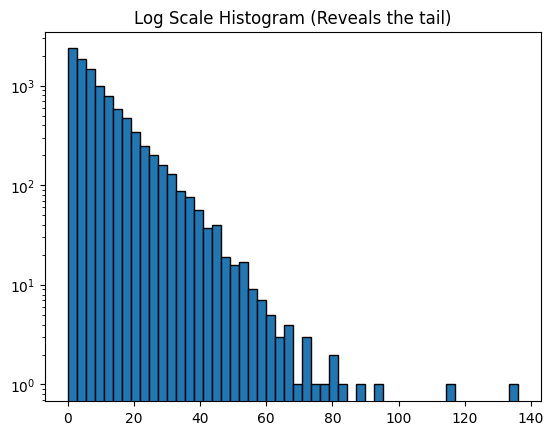

In [13]:
# Log Scale for highly skewed data
data = np.random.exponential(scale=10, size=10000)
plt.hist(data, bins=50, log=True, edgecolor='black')
plt.title('Log Scale Histogram (Reveals the tail)')
plt.show()


### ⚠️ Common Mistakes
*   **The Bin Trap:** Too few bins hides the shape (underfitting). Too many bins creates noise (overfitting).
*   **Log Scale on Zeros:** `log=True` will crash if your data contains `0` or negative numbers, because `log(0)` is undefined.

### 🎤 Interview Questions
1.  **Q:** What is the difference between a Bar Chart and a Histogram?
    **A:** Bar Chart compares discrete categories (gaps between bars). Histogram shows distribution of continuous numerical data (no gaps).
2.  **Q:** When should you use a logarithmic scale (`log=True`) in a histogram?
    **A:** When your data is heavily skewed (e.g., income, house prices) and a few massive outliers are squishing the rest of the data into a single bar.

### 🎯 Practice Tasks
**🟢 Easy Tasks (3)**
1. Generate 100 random ages and plot a basic histogram.
2. Change the number of bins to 10 and then to 50. Observe the change.
3. Add an edge color to the bars.

**🟡 Medium Tasks (3)**
1. Define custom bins: `[0, 18, 35, 60, 100]` for demographic buckets.
2. Overlay a vertical line for the mean and median using `plt.axvline()`.
3. Plot a histogram with a logarithmic Y-axis (`log=True`).

**🔴 Hard Tasks (3)**
1. Plot two overlapping histograms (e.g., salaries of two different departments) using `alpha=0.5`.
2. Create a function that automatically calculates the optimal number of bins using the Square Root rule (`bins = int(np.sqrt(len(data)))`).
3. Add a KDE (Kernel Density Estimate) curve over the histogram.

### 🐛 Debugging Challenges (2)
1.  **Why does changing `bins=5` to `bins=50` completely change the story the chart tells?**
    *Answer: Bins dictate the resolution. 5 bins smooths out noise but hides detail. 50 bins shows detail but might look like random noise.*
2.  **Why does `plt.hist(data, log=True)` throw an error?**
    *Answer: Your dataset likely contains `0` or negative values. Logarithms are only defined for positive numbers.*

### 🚀 Real-World Mini Project
**Salary Distribution Analysis:** Generate a right-skewed dataset of 10,000 employee salaries (using exponential distribution). Plot the histogram. Notice how it's squished. Apply `log=True` to reveal the true distribution. Add vertical lines for the mean, median, and the 90th percentile.

### 📝 Revision Questions
1. What does the X-axis of a histogram represent?
2. Why are there no gaps between bars in a histogram?


---

# 📘 MODULE 6: Pie Charts (Proportions)

### 🧠 Concept
Pie charts show the percentage contribution of categories to a whole (100%).

### 💡 Why It Exists
To show **part-to-whole relationships**. However, human eyes are very bad at comparing angles, so they must be used sparingly.

### 🧩 Mental Model
**"Slicing a pizza."** Keep the number of slices small, or nobody will know who gets what.

### 📊 ASCII Diagram: Good vs Bad Pie
```text
Good Pie Chart (5 slices)     Bad Pie Chart (25 slices)
      ___                         ___
    /     \                     /  |  \
   |  40%  |                   | 1%|2%|
    \ ___ /                     \ _|_/
   Easy to read!               Impossible to read!
```

### 💻 Syntax
`plt.pie(sizes, labels=..., autopct='%0.1f%%', explode=..., shadow=True)`

### 💻 Code Example


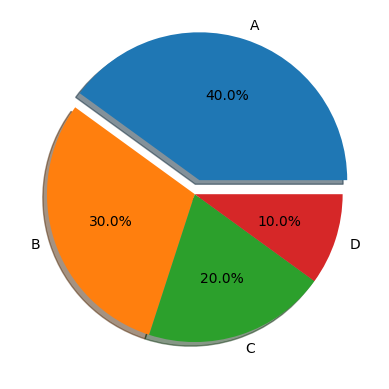

In [14]:
sizes = [40, 30, 20, 10]
labels = ['A', 'B', 'C', 'D']
explode = [0.1, 0, 0, 0] # Pull out the first slice
plt.pie(sizes, labels=labels, autopct='%0.1f%%', explode=explode, shadow=True)
plt.show()


### ⚠️ Common Mistakes
*   **The "Too Many Slices" Trap:** Using a pie chart for more than 5-6 categories.
*   **The 3D Trap:** 3D pie charts distort the area of the slices at the front vs the back.

### 🎤 Interview Questions
1.  **Q:** When should Pie Charts be avoided?
    **A:** When you have more than 5-6 categories, or when you need to make precise comparisons between slices (use a bar chart instead).
2.  **Q:** What does the `explode` parameter do?
    **A:** It takes an array of the same length as your data and "pulls out" specific slices by the specified fraction to highlight them.

### 🎯 Practice Tasks
**🟢 Easy Tasks (3)**
1. Create a simple pie chart for 4 subjects' marks.
2. Add percentages inside the slices using `autopct`.
3. Change the colors of the slices.

**🟡 Medium Tasks (3)**
1. "Explode" (pull out) the largest slice by 0.1.
2. Add a shadow to the pie chart.
3. Start the first slice at 90 degrees (`startangle=90`).

**🔴 Hard Tasks (3)**
1. Create a "Donut Chart" by adding a white circle in the center using `wedgeprops=dict(width=0.3)`.
2. Write a function that automatically calculates the `explode` array to pull out *only* the maximum slice.
3. Convert a 10-category pie chart into a bar chart. Which is easier to read and why?

### 🐛 Debugging Challenges (2)
1.  **Why does `plt.pie(data, explode=[0.1, 0.1])` throw an error if `data` has 5 elements?**
    *Answer: The `explode` array must have the exact same length as the `data` array.*
2.  **Why is a pie chart a bad choice for showing "Sales over 12 months"?**
    *Answer: Time is continuous and ordered. A pie chart destroys the chronological order, making trends impossible to see.*

### 🚀 Real-World Mini Project
**Company Expense Breakdown:** You have a list of company expenses. Group all expenses that are less than 2% of the total into an "Other" category (to keep the pie chart under 6 slices). Plot the pie chart, explode the largest expense category, and add a legend instead of direct labels to avoid clutter.

### 📝 Revision Questions
1. What is the maximum recommended number of slices in a pie chart?
2. How do you display percentages on a pie chart?


---

# 📘 MODULE 7: Styling & Saving Figures

### 🧠 Concept
Matplotlib's default style is basic. You can apply themes and save high-resolution images.

### 💡 Why It Exists
To make plots **publication-ready, professional, and reproducible** for reports or dashboards.

### 🧩 Mental Model
**"Dressing up the canvas and framing the art."**

### 📊 ASCII Diagram: The Workflow
```text
1. plt.style.use('ggplot')  -> Put on a nice suit
2. Plot your data            -> Paint the masterpiece
3. plt.savefig('plot.png')  -> Frame it and hang it
4. plt.show()                -> Show it to the audience
```

### 💻 Syntax
*   `plt.style.use('theme_name')`
*   `plt.savefig('filename.png', dpi=300, bbox_inches='tight')`

### 💻 Code Example


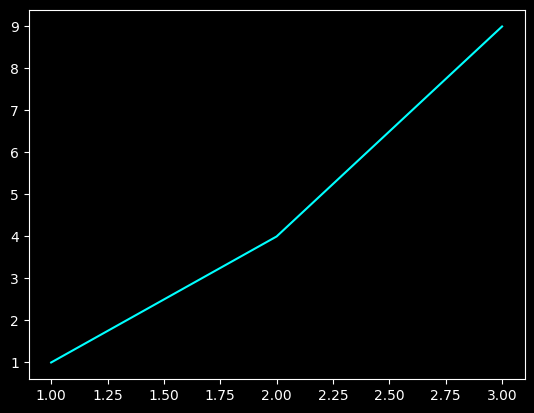

In [15]:
plt.style.use('dark_background')
plt.plot([1, 2, 3], [1, 4, 9], color='cyan')
# CRITICAL: Save BEFORE show!
plt.savefig('dark_plot.png', dpi=300, bbox_inches='tight')
plt.show()


### ⚠️ Common Mistakes
*   **The Blank Image Trap:** Calling `plt.savefig()` *after* `plt.show()`. `show()` clears the canvas from memory!
*   **The Style Bleed:** Forgetting to reset the style, causing all subsequent notebooks/plots to look weird.

### 🎤 Interview Questions
1.  **Q:** What is the difference between `plt.savefig()` and `plt.show()`?
    **A:** `savefig()` writes the canvas to a file on disk. `show()` renders it to the screen and clears the memory.
2.  **Q:** Why should you use `bbox_inches='tight'` when saving?
    **A:** It automatically crops the whitespace around the figure, ensuring labels and titles aren't cut off.

### 🎯 Practice Tasks
**🟢 Easy Tasks (3)**
1. Print all available styles using `plt.style.available`.
2. Apply the `ggplot` style to a simple line plot.
3. Save the plot as `my_plot.png`.

**🟡 Medium Tasks (3)**
1. Apply the `dark_background` style and plot with neon colors.
2. Save the figure as a high-resolution PDF (`dpi=300`).
3. Save the figure with a transparent background (`transparent=True`).

**🔴 Hard Tasks (3)**
1. Use `plt.style.context('seaborn')` to apply a style to only *one* specific plot without changing the global state.
2. Write a loop that generates and saves 5 different plots using 5 different styles.
3. Modify `plt.rcParams` directly to change the default font size and line width globally.

### 🐛 Debugging Challenges (2)
1.  **Why did I just save an image, but when I open the file, it's completely blank?**
    *Answer: You called `plt.savefig()` after `plt.show()`. The canvas was already cleared.*
2.  **Why did my `dark_background` style make my black lines invisible?**
    *Answer: Dark background sets the canvas to black. If your line color is black (or default), it blends in. Explicitly set `color='white'` or `color='cyan'`.*

### 🚀 Real-World Mini Project
**Automated Report Generator:** Write a Python script that loops through a list of 3 datasets. For each dataset, it generates a styled line plot, applies the `fivethirtyeight` theme, adds a professional title, and saves it as a high-DPI PNG file in a specific folder.

### 📝 Revision Questions
1. When should you call `plt.savefig()` relative to `plt.show()`?
2. What does `dpi=300` mean?